In [ ]:
import pandas as pd
import numpy as np
import csv
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import BertTokenizer, BertForSequenceClassification
import torch
import os
import yfinance as yf
from transformers import pipeline
from huggingface_hub import login
import matplotlib.pyplot as plt
from datetime import datetime

load_dotenv()
token = os.getenv('HF_TOKEN')
login(token)


c:\Users\hmaxw\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
NewsAPI_data = pd.DataFrame(pd.read_csv('NewsAPI_data_multipleday.csv',encoding='utf-8'))
NewsAPI_data['type'] = 'news'
NewsAPI_data.drop_duplicates(subset=['title'],inplace=True)
NewsAPI_data['date'] = pd.to_datetime(NewsAPI_data['publishedAt']).dt.strftime('%y%m%d')
NewsAPI_data_needed = NewsAPI_data[['title','description','content','date']]

In [3]:
prosus_model= AutoModelForSequenceClassification.from_pretrained('ProsusAI/finbert')
prosus_tokenizer = AutoTokenizer.from_pretrained('ProsusAI/finbert')
# finbert_model = BertForSequenceClassification.from_pretrained('yiyanghkust/finbert-tone',num_labels=3)
# tokenizer_tokenizer = BertTokenizer.from_pretrained('yiyanghkust/finbert-tone')

nlp1 = pipeline('text-classification', model=prosus_model, tokenizer=prosus_tokenizer, truncation=True, max_length=512,batch_size=32)
# nlp2 = pipeline('text-classification', model=finbert_model, tokenizer=tokenizer_tokenizer, truncation=True, max_length=512,batch_size=32)

def pos_neg_neu1(texts):
    results1 = nlp1([i if isinstance(i, str) and i.strip() else ' ' for i in texts])
    return [ i['score'] if i['label'] == 'positive' else -i['score'] if i['label'] == 'negative' else 0 for i in results1]
 
# def pos_neg_neu2(texts):
#     results2 = nlp2([i if isinstance(i, str) and i.strip() else ' ' for i in texts])
#     return [ i['score'] if i['label'] == 'Positive' else -i['score'] if i['label'] == 'Negative' else 0 for i in results2]

NewsAPI_data_needed['title_score_prosus'] = pos_neg_neu1(NewsAPI_data_needed['title'])
NewsAPI_data_needed['description_score_prosus'] = pos_neg_neu1(NewsAPI_data_needed['description'])
NewsAPI_data_needed['content_score_prosus'] = pos_neg_neu1(NewsAPI_data_needed['content'])
NewsAPI_data_needed['final_score_prosus'] = NewsAPI_data_needed[['title_score_prosus', 'description_score_prosus','content_score_prosus']].mean(axis=1)

# NewsAPI_data_needed['title_score_yiyanghkust'] = pos_neg_neu2(NewsAPI_data_needed['title'])
# NewsAPI_data_needed['description_score_yiyanghkust'] = pos_neg_neu2(NewsAPI_data_needed['description'])
# NewsAPI_data_needed['final_score_yiyanghkust'] = NewsAPI_data_needed[['title_score_yiyanghkust', 'description_score_yiyanghkust']].mean(axis=1)

# NewsAPI_data_needed['score'] = NewsAPI_data_needed[['final_score_yiyanghkust','final_score_prosus']].mean(axis=1)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 8154.76it/s]
BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [4]:
NewsAPI_data_needed.reset_index(drop=True, inplace=True)
NewsAPI_data_needed.to_csv('NewsAPI_data_multipleday_withscores.csv', index=False, encoding='utf-8')


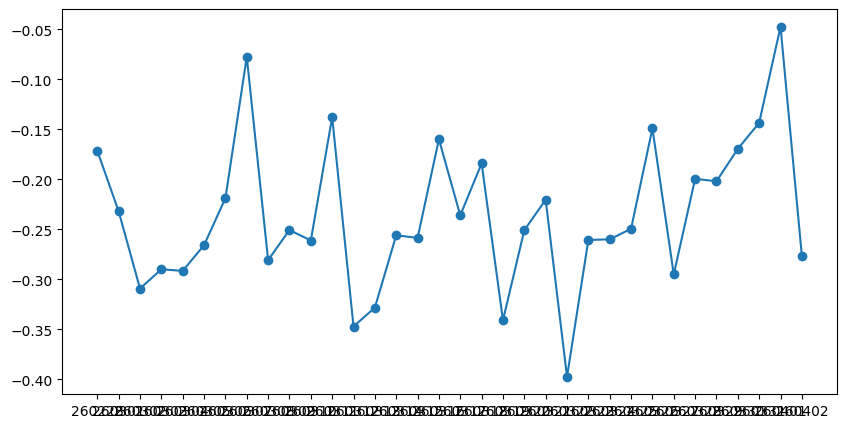

In [5]:
temp = NewsAPI_data_needed.groupby('date')['final_score_prosus'].mean() 
plt.figure(figsize=(10, 5))
plt.plot(temp.index, temp.values, marker='o')


In [6]:
temp

date
260228   -0.171471
260301   -0.231969
260302   -0.309144
260303   -0.289864
260304   -0.291451
260305   -0.265674
260306   -0.218802
260307   -0.077499
260308   -0.280686
260309   -0.250588
260310   -0.261077
260311   -0.137738
260312   -0.347077
260313   -0.328151
260314   -0.255865
260315   -0.258460
260316   -0.159907
260317   -0.235938
260318   -0.183988
260319   -0.340804
260320   -0.250757
260321   -0.220318
260322   -0.397324
260323   -0.260536
260324   -0.259945
260325   -0.249330
260326   -0.148983
260327   -0.294961
260328   -0.199374
260329   -0.201869
260330   -0.169473
260331   -0.143366
260401   -0.047393
260402   -0.276514
Name: final_score_prosus, dtype: float64

In [ ]:
oil_volatility_index = yf.download('^OVX', start='2026-02-28', end=datetime.today().date())
oil_volatility_index['avg'] = oil_volatility_index[['Open','Close']].mean(axis=1)
oil_volatility_index= oil_volatility_index[['avg']]

oil_volatility_index

[*********************100%***********************]  1 of 1 completed


Price,avg
Ticker,
Date,
2026-03-02,71.420002
2026-03-03,75.770000
2026-03-04,77.064999
2026-03-05,81.360001
2026-03-06,98.055000
2026-03-09,106.130001
2026-03-10,106.855000
2026-03-11,114.970001
